In [604]:
# Manipulación de datos
import numpy as np
import pandas as pd

# Advertencias
import warnings
warnings.filterwarnings('ignore')

#Graficos
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from plotly import tools


#Preparación de datos
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn import set_config

#Modelado
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

#Evaluación
from sklearn.metrics import accuracy_score, confusion_matrix

# OBJETIVO
Practicar graficos para hacer un EDA exitoso
Hacer EDAS que permitan visualizar las caracteristicas de las variables

# Bases de datos

In [607]:
df = pd.read_csv('bank.csv')
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


In [608]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [609]:
# Promedio de la edad

In [610]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


## Problemas Numpy and pandas

### Problema 1:
Un banco quiere identificar a los clientes con mayor potencial para abrir un depósito (deposit) basándose en su edad (age) y balance (balance). Quieren saber cuántos clientes tienen una edad entre 25 y 45 años y además tienen un balance mayor a 5000. También quieren calcular el balance promedio de estos clientes.

Tareas:
1. Filtrar los clientes que tienen edad entre 25 y 45 años y balance > 5000.
2. Contar cuántos clientes cumplen estas condiciones.
3. Calcular el balance promedio de estos clientes.

In [613]:
# 1. Clientes entre 25 y 45 años con un balance mayor a 5000
df_filtrado = df[(df['age'] >= 25) & (df['age'] <=45) & (df['balance'] > 5000)]
# 2. Clientes con esas condiciones
df_clientes = df_filtrado.shape[0]
print(f"Numero de clientes con edad entre 25 y 45 años y con una balance mayor a $5000 = {df_clientes}.")
# 3. Calcular el balance promedio de estos clientes
df_filtrado_balance = df_filtrado['balance'].mean()
print(f"balance promedio de los clientes filtrados {df_filtrado_balance}.")

Numero de clientes con edad entre 25 y 45 años y con una balance mayor a $5000 = 440.
balance promedio de los clientes filtrados 9477.075.


### Problema 2:

Un equipo de marketing quiere analizar la efectividad de las campañas (campaign) en función del resultado de la campaña anterior (poutcome). Quieren saber:
1. Cuántas campañas se hicieron (campaign) para clientes donde el resultado de la campaña anterior (poutcome) fue "success".
2. El número promedio de campañas (campaign) para clientes con poutcome "failure".
3. El número promedio de campañas (campaign) para clientes con poutcome "success".

In [615]:
# 1. Campañas exitosas anteriores 'poutcome'
df_success = df[df['poutcome'] == "success"]
df_success_cantidad = df_success.shape[0]
print(f"1. clientes con campañas anteriores exitosas {df_success_cantidad}")

# 2. Promedio de campañas anteriores 'fallidas'
promedio_fallido = df[df['poutcome'] == 'failure']['campaign'].mean()
print(f"2. promedio de campañas fallidas {promedio_fallido}")

# 3. Promedio de campañas anteriores 'success'
promedio_exitos = df[df['poutcome'] == 'success']['campaign'].mean()
print(f"3. promedio de campañas exitosas {promedio_exitos}")


1. clientes con campañas anteriores exitosas 1071
2. promedio de campañas fallidas 1.8876221498371335
3. promedio de campañas exitosas 1.7413632119514473


### Problema 3

Ejercicio:
Un analista quiere entender mejor la distribución del balance (balance) según el estado marital (marital). Quiere:
1. Calcular el balance promedio para clientes solteros (marital == 'single').
2. Calcular el balance promedio para clientes casados (marital == 'married').
3. Comparar estos promedios para ver cuál grupo tiene un balance promedio mayor.


In [617]:
# 1. promedio de clientes solteros
promedio_solteros = df[df['marital'] == 'single']['balance'].mean()
print(f"1. balance promedio de clientes solteros {promedio_solteros}")

# 2. promedio de clientes casados
promedio_casados = df[df['marital'] == 'married']['balance'].mean()
print(f"2. balance promedio de clientes casasdos {promedio_casados}")

# 3. comparación de quienes ganan mas
if promedio_solteros > promedio_casados:
    print(f"3. Clientes solteros tienen un mayor balnce: {promedio_solteros} vs {promedio_casados}")
elif promedio_casados > promedio_solteros:
    print(f"3. Clientes casados tienen un mayor balance: {promedio_casados} vs {promedio_solteros}")
else:
    print(f"3. Balances promedio son iguales: solteros={promedio_solteros}, casados={promedio_casados}")


1. balance promedio de clientes solteros 1457.2552586696986
2. balance promedio de clientes casasdos 1599.9275704613447
3. Clientes casados tienen un mayor balance: 1599.9275704613447 vs 1457.2552586696986


# ELIMINACION DE NULOS

In [619]:
datos_nulos = df.isnull().sum()
datos_nulos

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

nulos_viviendas = df_viviendas.isnull().sum()
nulos_viviendas

# EDA CATEGORICAS

## Graficos con plotly

## Variables Categoricas

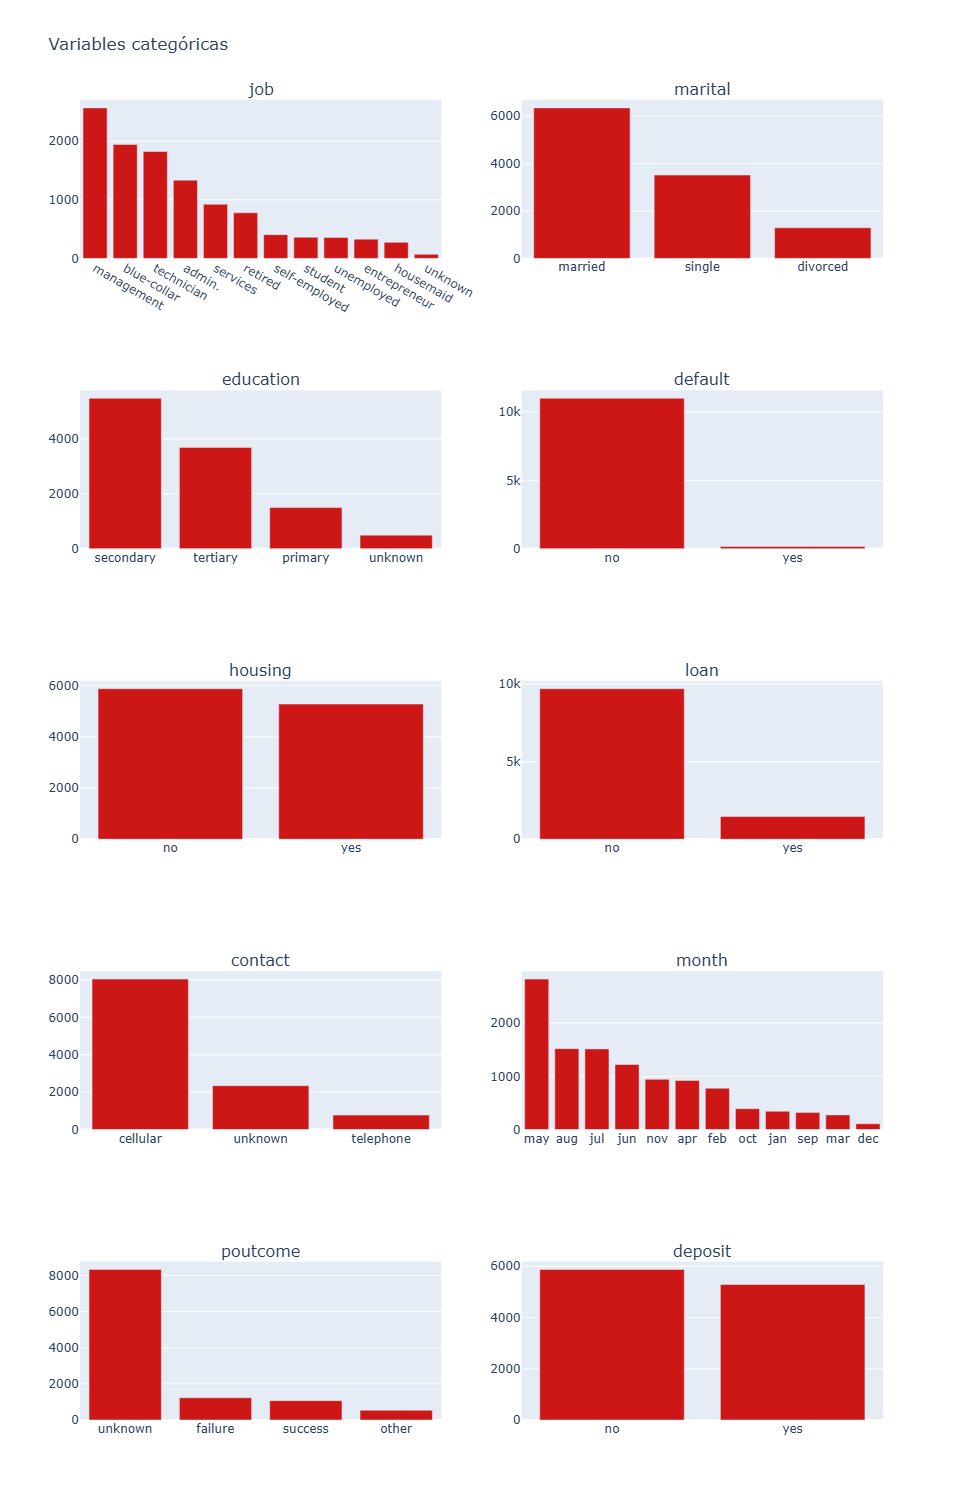

In [624]:
categoricas = df.select_dtypes(include=["object"]).columns.tolist()

cols = 2
rows = (len(categoricas) + cols - 1) // cols

# Crear subplots
fig = make_subplots(rows=rows, cols=cols, subplot_titles=categoricas)

# Agregar un gráfico de barras por cada variable categórica
for i, var in enumerate(categoricas):
    row = i // cols + 1
    col = i % cols + 1
    
    # Contar frecuencias de cada categoría y ordenar de forma descendente
    value_counts = df[var].value_counts().sort_values(ascending=False)
    
    fig.add_trace(
        go.Bar(x=value_counts.index, y=value_counts.values, name=var, marker_color="#cd1616"),
        row=row, col=col
    )
        
# Ajustes de presentación
fig.update_layout(
    height=300 * rows,
    width=1400,
    title_text='Variables categóricas',
    template='plotly',
    showlegend=False
)

fig.show()

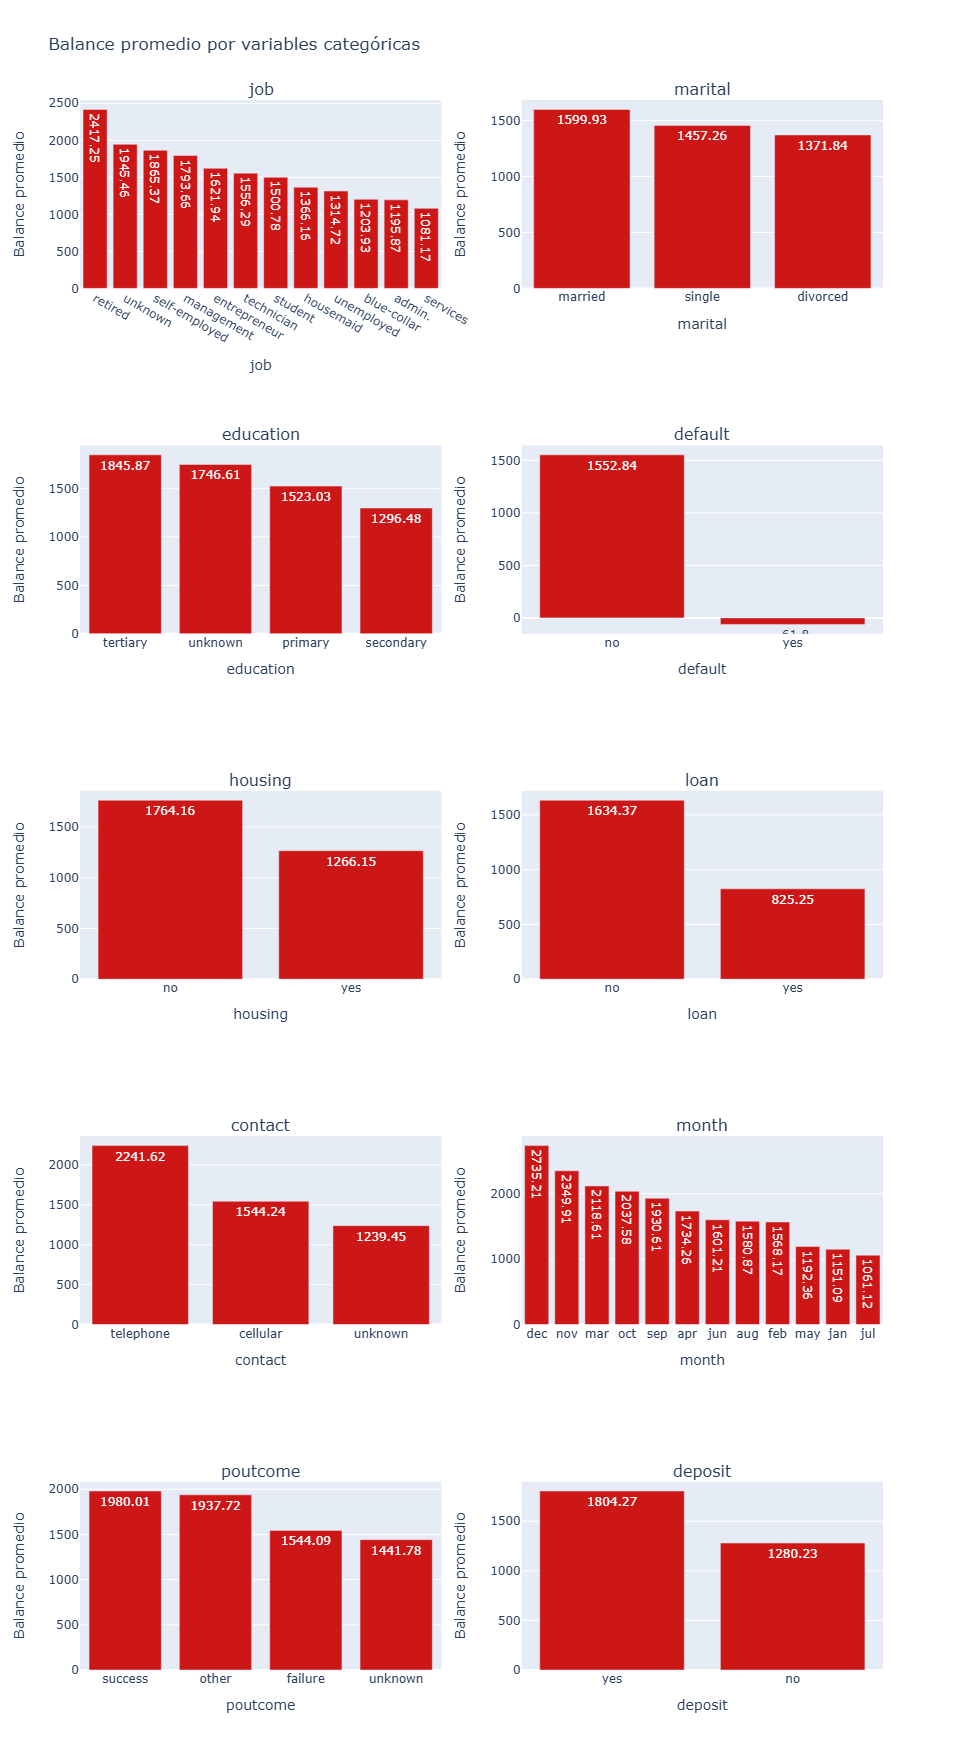

In [625]:
### Variables categoricas por balance

import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Asumiendo que ya tienes un DataFrame llamado df con una columna 'balance'
categoricas = df.select_dtypes(include=["object"]).columns.tolist()

cols = 2
rows = (len(categoricas) + cols - 1) // cols

# Crear subplots
fig = make_subplots(rows=rows, cols=cols, subplot_titles=categoricas)

# Agregar un gráfico de barras por cada variable categórica relacionado con el balance
for i, var in enumerate(categoricas):
    row = i // cols + 1
    col = i % cols + 1
    
    # Calcular el balance promedio por cada categoría
    balance_por_categoria = df.groupby(var)['balance'].mean().sort_values(ascending=False)
    
    fig.add_trace(
        go.Bar(
            x=balance_por_categoria.index, 
            y=balance_por_categoria.values, 
            name=var, 
            marker_color="#cd1616",
            text=balance_por_categoria.values.round(2),  # Mostrar valores en las barras
            textposition='auto'
        ),
        row=row, col=col
    )
    
    # Actualizar títulos de los ejes para cada subplot
    fig.update_xaxes(title_text=var, row=row, col=col)
    fig.update_yaxes(title_text="Balance promedio", row=row, col=col)
        
# Ajustes de presentación
fig.update_layout(
    height=350 * rows,  # Un poco más alto para acomodar las etiquetas
    width=1400,
    title_text='Balance promedio por variables categóricas',
    template='plotly',
    showlegend=False
)

fig.show()

### Tipo de trabajo

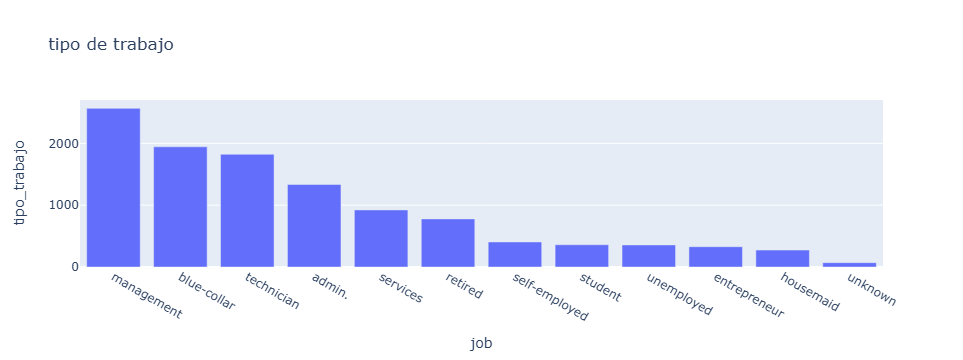

In [627]:
# Grafico con plotly de una sola variable categorica

tipo_trabajo = df["job"].value_counts().reset_index()
tipo_trabajo.columns = ["job", "tipo_trabajo"]

fig = px.bar(tipo_trabajo, x="job", y="tipo_trabajo", title = "tipo de trabajo")
fig.show()

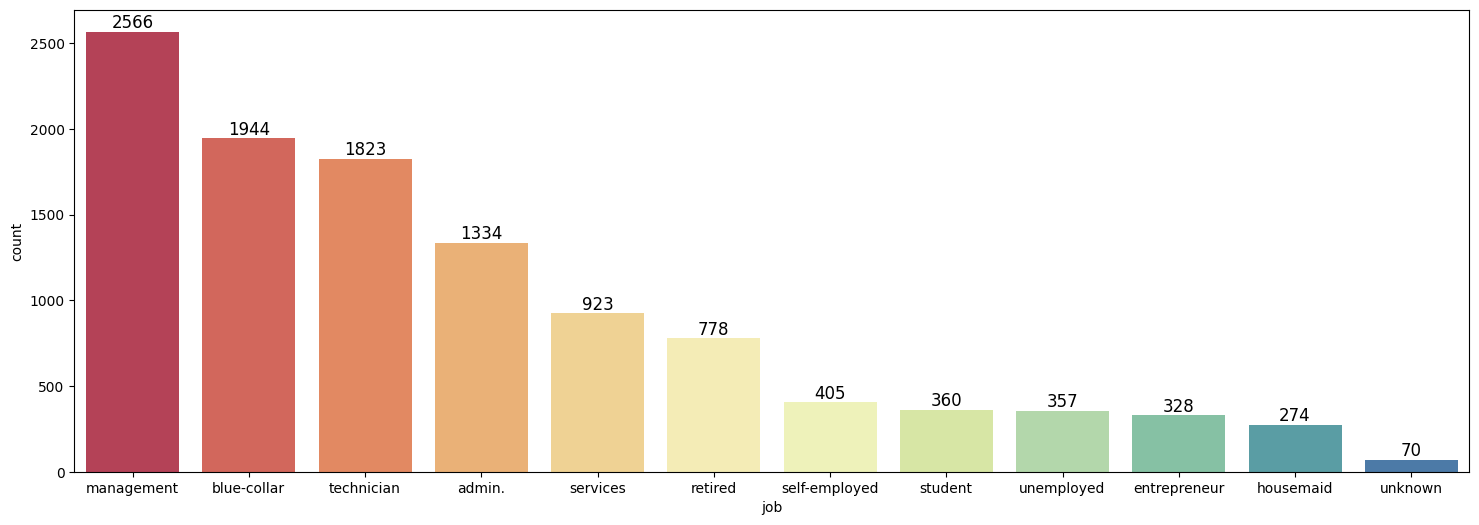

In [628]:
# Calcular el conteo de cada categoría de trabajo
job_counts = df['job'].value_counts().reset_index()
job_counts.columns = ['job', 'count']  # This is fine as column name

# Crear una lista ordenada de categorías de trabajo
order = job_counts['job'].tolist()

# If you have a variable named 'count' defined elsewhere, clear it
# del count  # Uncomment this if you have a variable named 'count'

plt.figure(figsize=(18, 6))
ax = sns.countplot(data=df, x="job", order=order, palette="Spectral")

# Agregar conteo encima de cada barra
for i in ax.containers:
    ax.bar_label(i, label_type='edge', fontsize=12, color="black")
    

# Mostrar el gráfico
plt.show()

### Estado Marital

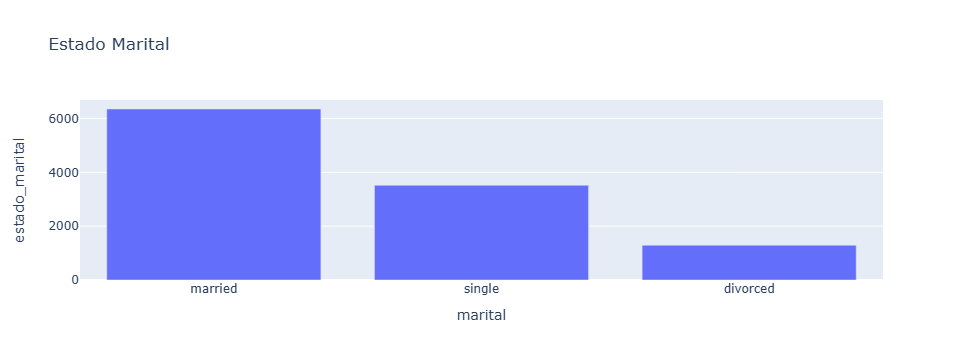

In [630]:
estado_marital = df["marital"].value_counts().reset_index()
estado_marital.columns = ["marital", "estado_marital"]

fig = px.bar(estado_marital, x="marital", y="estado_marital", title="Estado Marital")
fig.show()

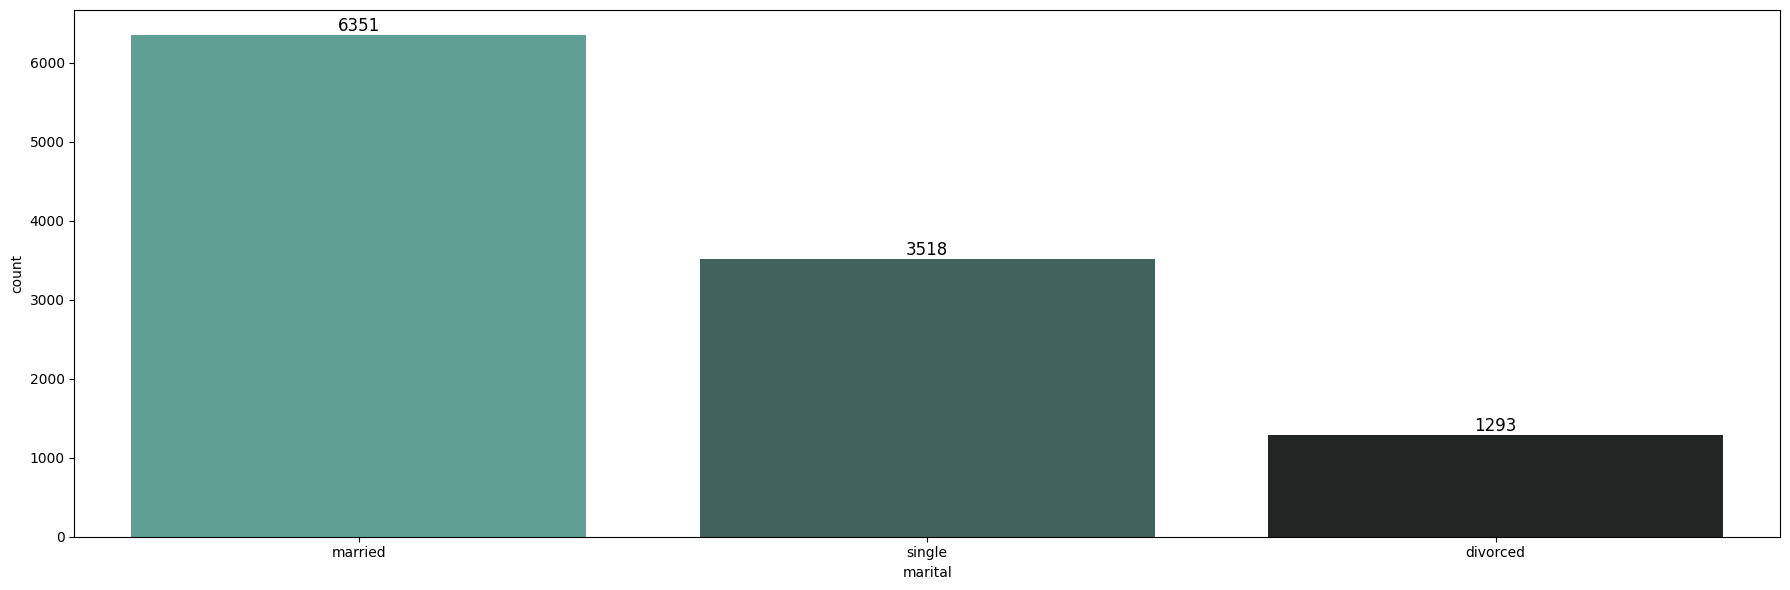

In [631]:
# Calcular el conteo de cada categoría
order_marital = df["marital"].value_counts().reset_index()
order_marital.columns = ["marital", "order_marital"]

# Crear una lista ordenada
order = order_marital["marital"].tolist()

# Crear la figura
plt.figure(figsize=(18, 6))
ax = sns.countplot(data=df, x="marital", order=order, palette="dark:#5A9_r")

# Agregar el numero encima de cada barra
for i in ax.containers:
    ax.bar_label(i, label_type="edge", fontsize=12, color="black")
    
# Personalizar el grafico
plt.title="Estado Marital"
plt.xlabel="Estado"
plt.ylabel="Cantidad"

# Mostrar el gráfico
plt.tight_layout()
plt.show()

### Tipo de Educación 

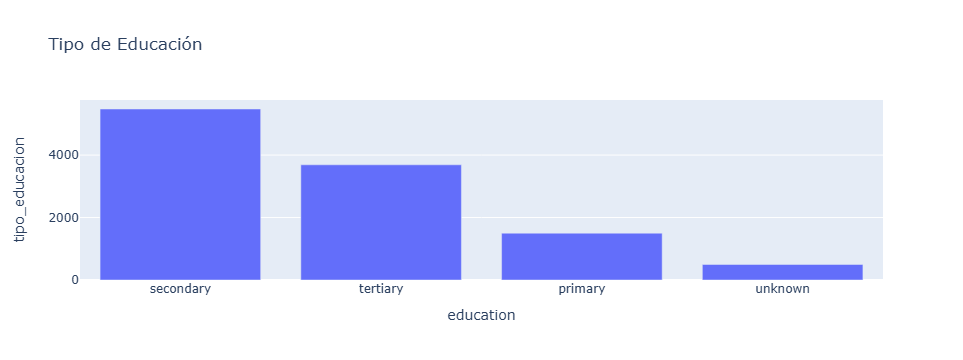

In [633]:
tipo_educacion = df["education"].value_counts().reset_index()
tipo_educacion.columns = ["education", "tipo_educacion"]

fig = px.bar(tipo_educacion, x="education", y="tipo_educacion", title="Tipo de Educación")
fig.show()

### Ultimo mes de contacto del año (month)

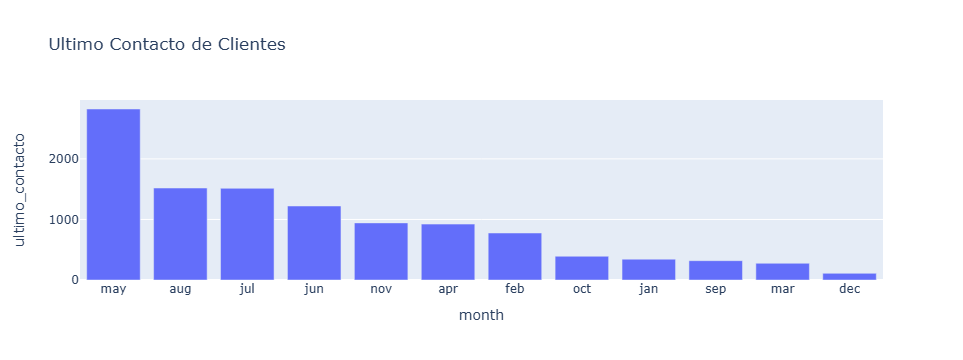

In [635]:
ultimo_contacto = df["month"].value_counts().reset_index()
ultimo_contacto.columns = ["month", "ultimo_contacto"]

fig = px.bar(ultimo_contacto, x="month", y="ultimo_contacto", title="Ultimo Contacto de Clientes")
fig.show()

# EDA NUMERICAS

## Variables Numéricas

### Histogramas plotly

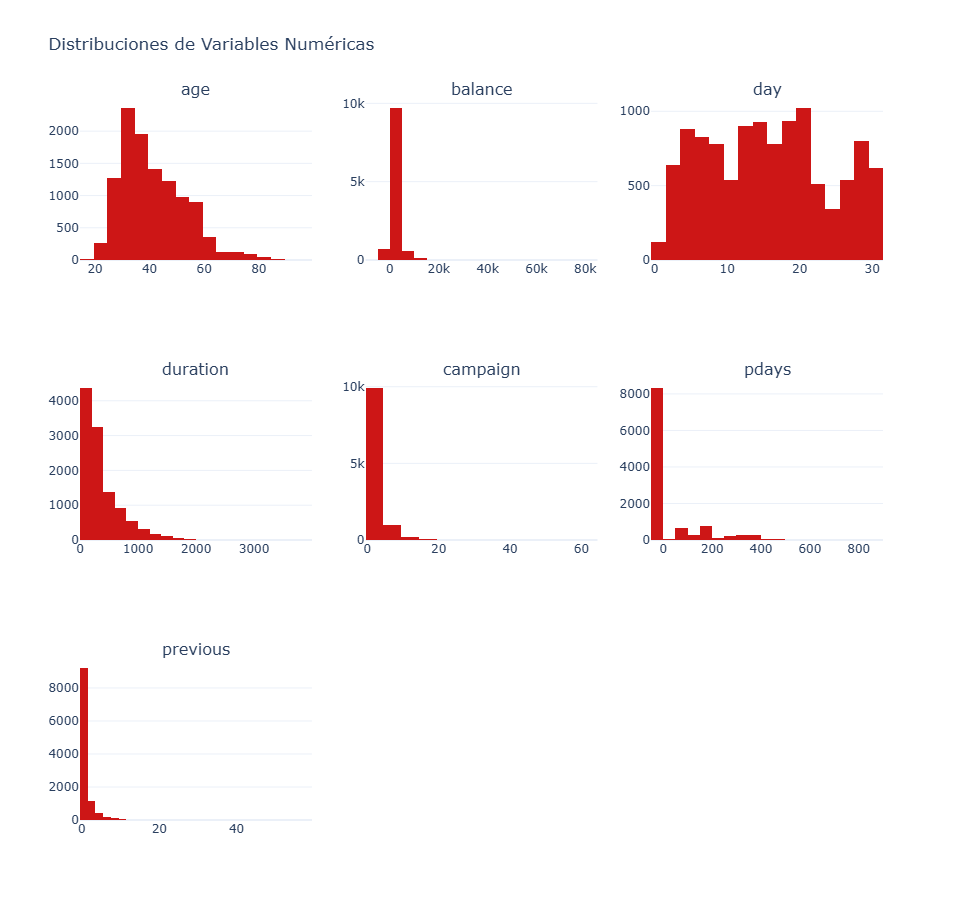

In [639]:
numericas = df.select_dtypes(include=["int", "float"]).columns.tolist()

# Número de columnas por fila (ajústalo según cuántas variables tengas)
cols = 3
rows = (len(numericas) + cols - 1) // cols  # redondeo hacia arriba

# Crear subplots
fig = make_subplots(rows=rows, cols=cols, subplot_titles=numericas)

# Agregar un histograma por variable
for i, var in enumerate(numericas):
    row = i // cols + 1
    col = i % cols + 1
    fig.add_trace(
        go.Histogram(x=df[var], name=var, marker_color="#cd1616", nbinsx=30),
        row=row, col=col
    )

# Ajustes de presentación
fig.update_layout(
    height=300 * rows,
    width=1400,
    title_text='Distribuciones de Variables Numéricas',
    template='plotly_white',
    showlegend=False
)

fig.show()

### Boxplot con plotly

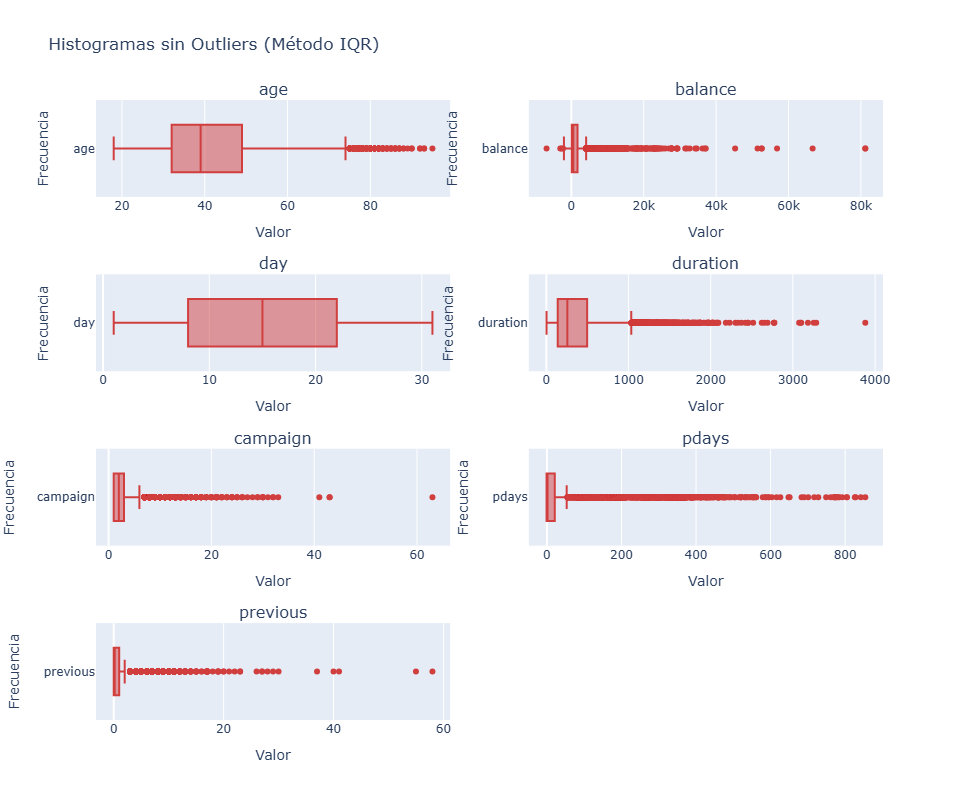

In [641]:
# Número de columnas por fila (ajústalo según cuántas variables tengas)
cols = 2
rows = (len(numericas) + cols - 1) // cols  # redondeo hacia arriba

# Crear subplots
fig = make_subplots(rows=rows, cols=cols, subplot_titles=numericas)

# Agregar un histograma por variable
for i, var in enumerate(numericas):
    row = i // cols + 1
    col = i % cols + 1
    fig.add_trace(
        go.Box(x=df[var], name=var, marker_color="#d13e3e"),
        row=row, col=col
    )
    
# Actualizar diseño
fig.update_layout(height=800, width=1300, title_text="Histogramas sin Outliers (Método IQR)",
                  showlegend=False)
fig.update_xaxes(title_text="Valor")
fig.update_yaxes(title_text="Frecuencia")

fig.show()


# NORMALIZACIÓN VARIABLES NUMERICAS IQR

In [643]:
# Diccionario para guardar outliers por variable
outliers_dict = {}

for var in numericas:
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = df[(df[var] < limite_inferior) | (df[var] > limite_superior)]
    outliers_dict[var] = outliers[[var]]
    print(f' ➡️ {var} - Número de outliers: {len(outliers)}')

 ➡️ age - Número de outliers: 171
 ➡️ balance - Número de outliers: 1055
 ➡️ day - Número de outliers: 0
 ➡️ duration - Número de outliers: 636
 ➡️ campaign - Número de outliers: 601
 ➡️ pdays - Número de outliers: 2750
 ➡️ previous - Número de outliers: 1258


## Boxplot Normalizados

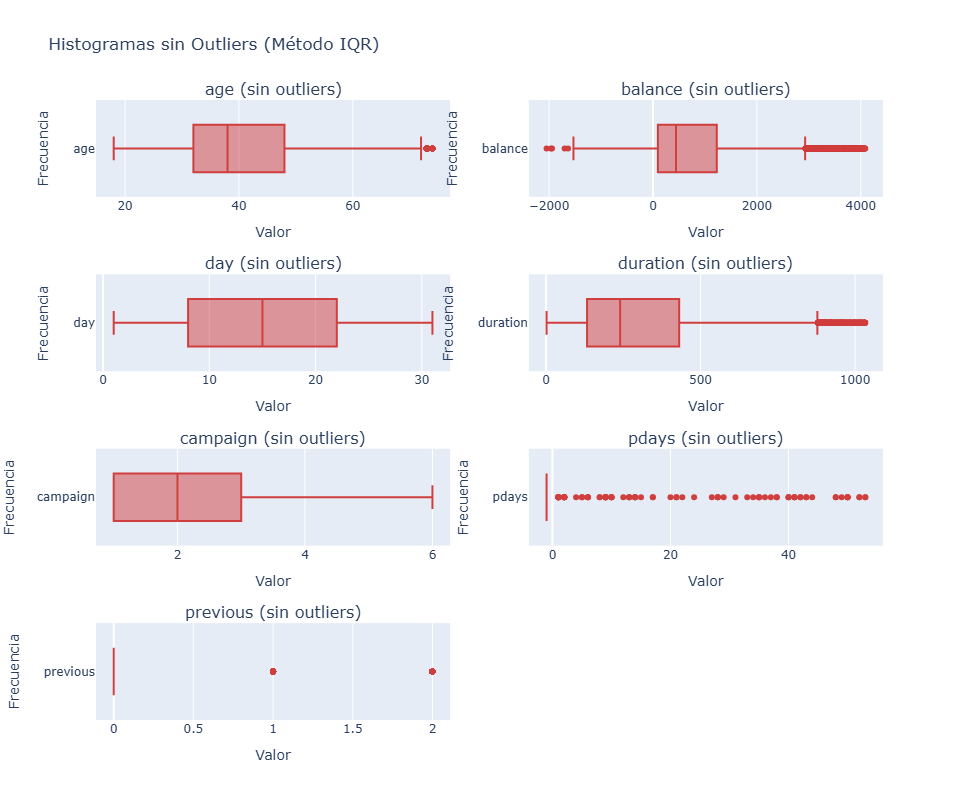

In [645]:
# Crear figura con subplots (2 columnas)
fig = make_subplots(rows=len(numericas)//2 + len(numericas)%2, cols=2,
                    subplot_titles=[f'{var} (sin outliers)' for var in numericas])

row = 1
col = 1

for i, var in enumerate(numericas):
    # Calcular límites sin outliers
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    
    # Filtrar sin outliers
    sin_outliers = df[(df[var] >= lim_inf) & (df[var] <= lim_sup)]
    
    # Agregar histograma
    fig.add_trace(
        go.Box(x=sin_outliers[var], name=var, marker_color="#d13e3e"),
        row=row, col=col
    )

    # Mover posición (columna y fila)
    if col == 1:
        col = 2
    else:
        col = 1
        row += 1

# Actualizar diseño
fig.update_layout(height=800, width=1300, title_text="Histogramas sin Outliers (Método IQR)",
                  showlegend=False)
fig.update_xaxes(title_text="Valor")
fig.update_yaxes(title_text="Frecuencia")

fig.show()

## Histograma Normalizado

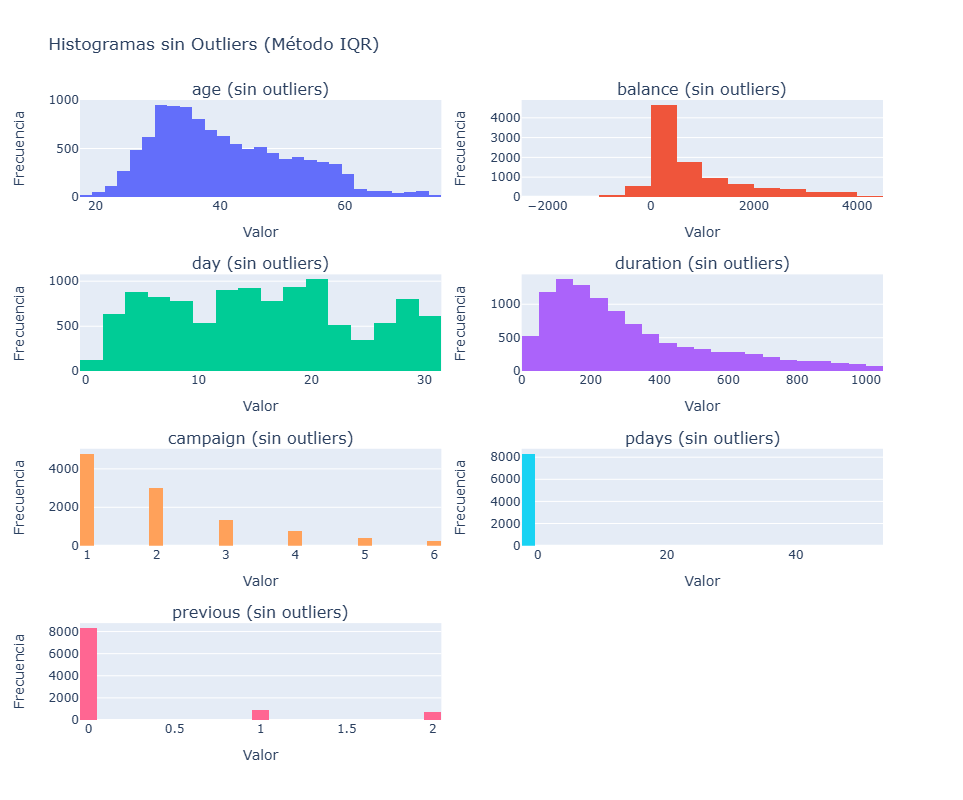

In [647]:
# Crear figura con subplots (2 columnas)
fig = make_subplots(rows=len(numericas)//2 + len(numericas)%2, cols=2,
                    subplot_titles=[f'{var} (sin outliers)' for var in numericas])

row = 1
col = 1

for i, var in enumerate(numericas):
    # Calcular límites sin outliers
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    
    # Filtrar sin outliers
    sin_outliers = df[(df[var] >= lim_inf) & (df[var] <= lim_sup)]
    
    # Agregar histograma
    fig.add_trace(go.Histogram(x=sin_outliers[var], nbinsx=30, name=var),
                  row=row, col=col)

    # Mover posición (columna y fila)
    if col == 1:
        col = 2
    else:
        col = 1
        row += 1

# Actualizar diseño
fig.update_layout(height=800, width=1300, title_text="Histogramas sin Outliers (Método IQR)",
                  showlegend=False)
fig.update_xaxes(title_text="Valor")
fig.update_yaxes(title_text="Frecuencia")

fig.show()

# GRAFICO DE DISPERSION

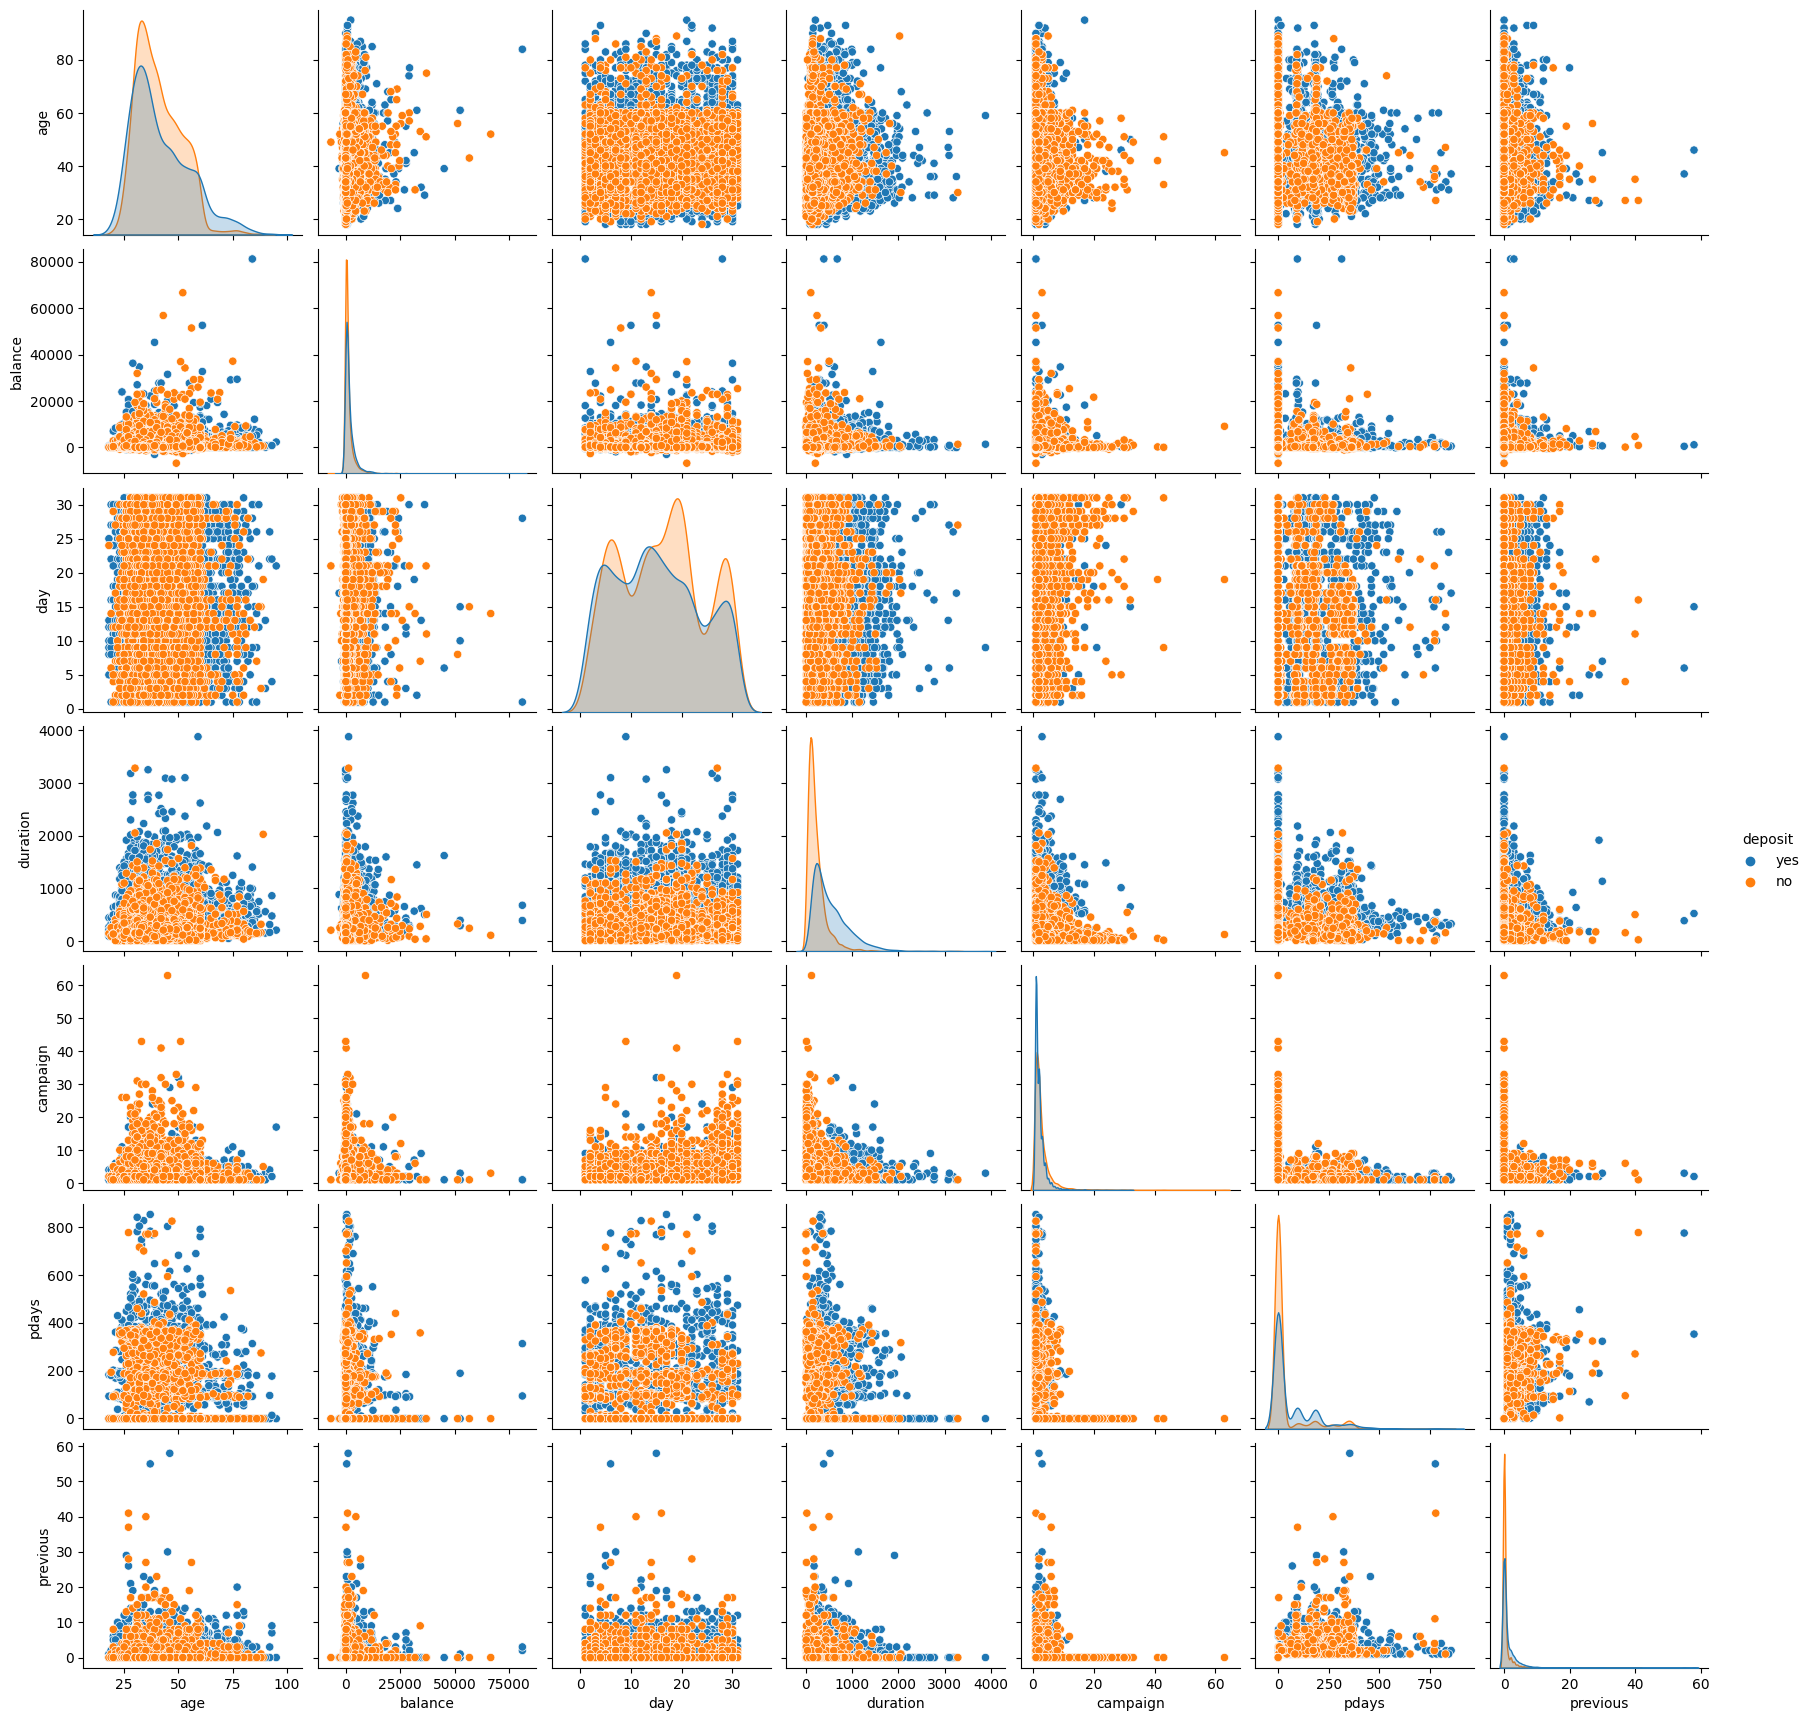

In [649]:
# identificación de grafica de dispersión con la varible objetivo
sns.pairplot(data=df, hue='deposit', kind = 'scatter')
plt.show()

# TRANSFORMACIÓN DE VARIABLES

In [651]:
# ORDENAR LAS VARIABLES PARA TRANSFORMARLAS
# Columnas numéricas
numCols = df.select_dtypes(include=['int64']).columns.to_list()

# Columnas categóricas con más de 2 valores (similar a ordCols, pero no necesariamente ordinales)
catCols = ['default', 'housing', 'loan']

# Ordinales
ordCols = ['education', 'month', 'contact', 'job', 'marital', 'poutcome', 'deposit']

In [652]:
#TRANSFORMACIÓN DE VARIABLES
numTransformer = Pipeline(steps=[('scaler', MinMaxScaler())])
catTransformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])
ordTransformer = Pipeline(steps = [('ordinal', OrdinalEncoder(handle_unknown = 'error'))])

In [653]:
preprocesador = ColumnTransformer(transformers = [
    ('num', numTransformer, numCols),
    ('cat', catTransformer, catCols),
    ('ord', ordTransformer, ordCols)
], remainder = 'passthrough')

set_config(display = 'diagram')
preprocesador

ColumnTransformer(remainder='passthrough',
                  transformers=[('num',
                                 Pipeline(steps=[('scaler', MinMaxScaler())]),
                                 ['age', 'balance', 'day', 'duration',
                                  'campaign', 'pdays', 'previous']),
                                ('cat',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['default', 'housing', 'loan']),
                                ('ord',
                                 Pipeline(steps=[('ordinal',
                                                  OrdinalEncoder())]),
                                 ['education', 'month', 'contact', 'job',
                                  'marital', 'poutcome', 'deposit'])])

In [654]:
datosPre = preprocesador.fit_transform(df)
datosPre

array([[0.53246753, 0.10437133, 0.13333333, ..., 1.        , 3.        ,
        1.        ],
       [0.49350649, 0.07827282, 0.13333333, ..., 1.        , 3.        ,
        1.        ],
       [0.2987013 , 0.09218521, 0.13333333, ..., 1.        , 3.        ,
        1.        ],
       ...,
       [0.18181818, 0.07809111, 0.6       , ..., 2.        , 3.        ,
        0.        ],
       [0.32467532, 0.07776175, 0.23333333, ..., 1.        , 0.        ,
        0.        ],
       [0.20779221, 0.07776175, 0.26666667, ..., 1.        , 3.        ,
        0.        ]])

In [655]:
codBin = preprocesador.named_transformers_['cat']['onehot'].get_feature_names_out(catCols)
labels = np.concatenate([numCols, codBin, ordCols])
labels

array(['age', 'balance', 'day', 'duration', 'campaign', 'pdays',
       'previous', 'default_no', 'default_yes', 'housing_no',
       'housing_yes', 'loan_no', 'loan_yes', 'education', 'month',
       'contact', 'job', 'marital', 'poutcome', 'deposit'], dtype=object)

In [656]:
datosPro = pd.DataFrame(datosPre, columns = labels)
datosPro.head()

,age,balance,day,duration,campaign,pdays,previous,default_no,default_yes,housing_no,housing_yes,loan_no,loan_yes,education,month,contact,job,marital,poutcome,deposit
0,0.532468,0.104371,0.133333,0.268110,0.000000,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,8.0,2.0,0.0,1.0,3.0,1.0
1,0.493506,0.078273,0.133333,0.377675,0.000000,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,8.0,2.0,0.0,1.0,3.0,1.0
2,0.298701,0.092185,0.133333,0.357566,0.000000,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,8.0,2.0,9.0,1.0,3.0,1.0
3,0.480519,0.105882,0.133333,0.148750,0.000000,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,8.0,2.0,7.0,1.0,3.0,1.0
4,0.467532,0.079851,0.133333,0.172983,0.016129,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,2.0,8.0,2.0,0.0,1.0,3.0,1.0


# HEADMAP

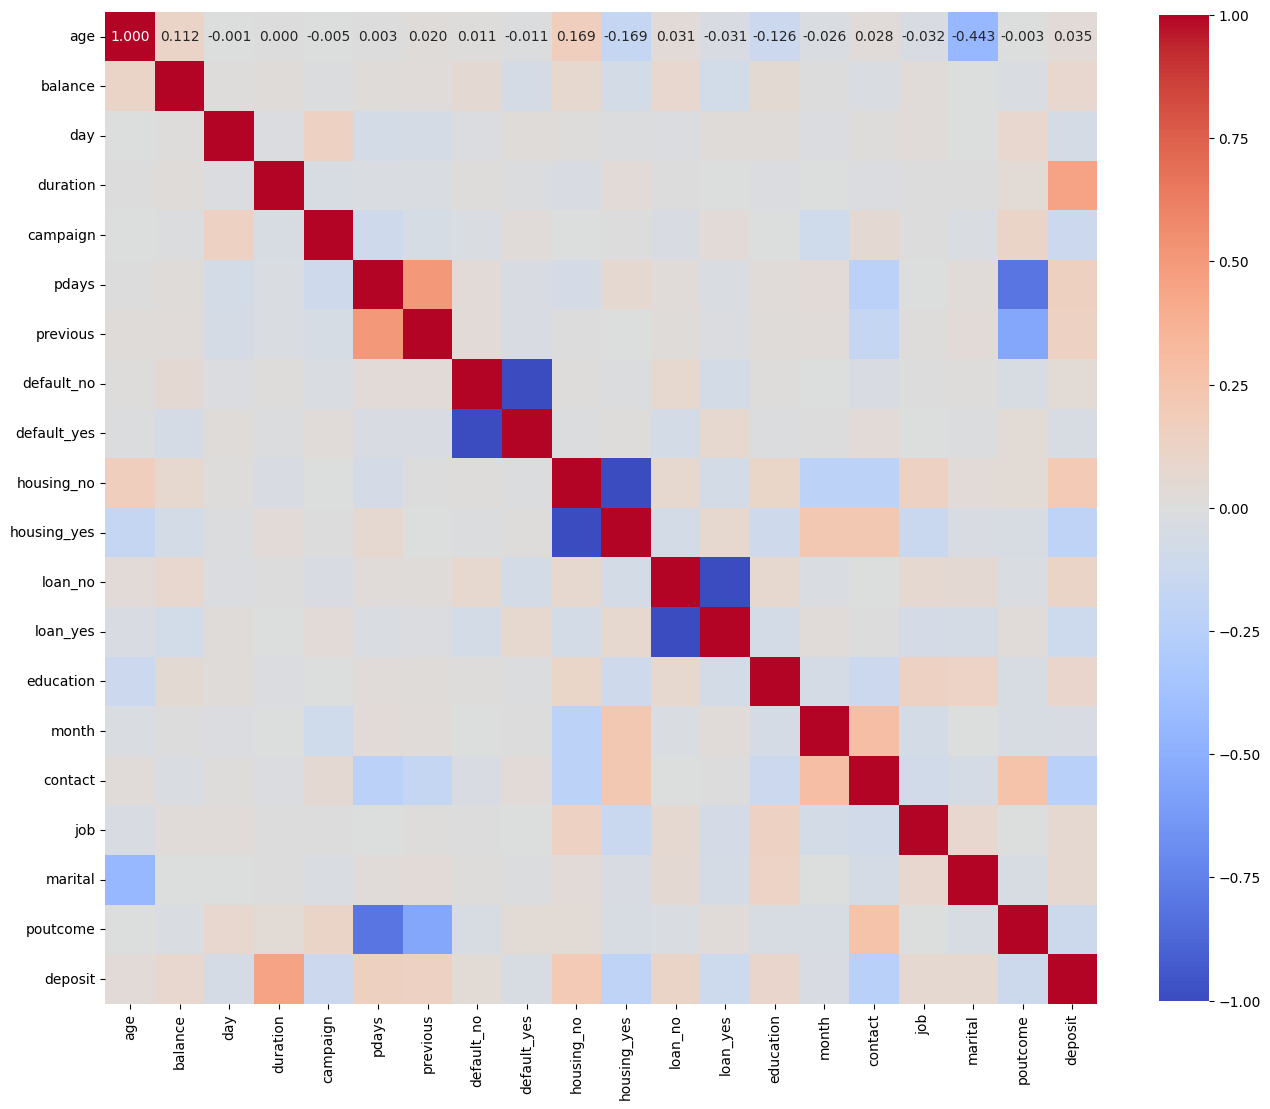

In [658]:
plt.figure(figsize = (16, 16))
sns.heatmap(datosPro.corr(), annot = True, fmt = '.3f', cmap = 'coolwarm', square = True, cbar_kws = {'shrink': .8})
plt.show()

# ENTRENAMIENTO

In [660]:
X = datosPro.drop('deposit', axis = 1)
y = datosPro['deposit']

In [661]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.8, random_state = 123)

In [662]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
 
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn import tree
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB


dict_classifiers = {
    "Logistic Regression": LogisticRegression(),
    "Nearest Neighbors": KNeighborsClassifier(),
    "Linear SVM": SVC(),
    "Gradient Boosting Classifier": GradientBoostingClassifier(),
    "Decision Tree": tree.DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=18),
    "Neural Net": MLPClassifier(alpha=1),
    "Naive Bayes": GaussianNB()
}

In [663]:
# Use Cross-validation.
from sklearn.model_selection import cross_val_score

# Logistic Regression
log_reg = LogisticRegression()
log_scores = cross_val_score(log_reg, X_train, y_train, cv=3)
log_reg_mean = log_scores.mean()

# SVC
svc_clf = SVC()
svc_scores = cross_val_score(svc_clf, X_train, y_train, cv=3)
svc_mean = svc_scores.mean()

# KNearestNeighbors
knn_clf = KNeighborsClassifier()
knn_scores = cross_val_score(knn_clf, X_train, y_train, cv=3)
knn_mean = knn_scores.mean()

# Decision Tree
tree_clf = tree.DecisionTreeClassifier()
tree_scores = cross_val_score(tree_clf, X_train, y_train, cv=3)
tree_mean = tree_scores.mean()

# Gradient Boosting Classifier
grad_clf = GradientBoostingClassifier()
grad_scores = cross_val_score(grad_clf, X_train, y_train, cv=3)
grad_mean = grad_scores.mean()

# Random Forest Classifier
rand_clf = RandomForestClassifier(n_estimators=18)
rand_scores = cross_val_score(rand_clf, X_train, y_train, cv=3)
rand_mean = rand_scores.mean()

# NeuralNet Classifier
neural_clf = MLPClassifier(alpha=1)
neural_scores = cross_val_score(neural_clf, X_train, y_train, cv=3)
neural_mean = neural_scores.mean()

# Naives Bayes
nav_clf = GaussianNB()
nav_scores = cross_val_score(nav_clf, X_train, y_train, cv=3)
nav_mean = neural_scores.mean()

# Create a Dataframe with the results.
d = {'Classifiers': ['Logistic Reg.', 'SVC', 'KNN', 'Dec Tree', 'Grad B CLF', 'Rand FC', 'Neural Classifier', 'Naives Bayes'], 
    'Crossval Mean Scores': [log_reg_mean, svc_mean, knn_mean, tree_mean, grad_mean, rand_mean, neural_mean, nav_mean]}

result_df = pd.DataFrame(data=d)

In [664]:
# All our models perform well but I will go with GradientBoosting.
result_df = result_df.sort_values(by=['Crossval Mean Scores'], ascending=False)
result_df

,Classifiers,Crossval Mean Scores
4,Grad B CLF,0.845112
5,Rand FC,0.833913
0,Logistic Reg.,0.789002
6,Neural Classifier,0.788778
7,Naives Bayes,0.788778
3,Dec Tree,0.774668
2,KNN,0.711054
1,SVC,0.706574


In [665]:
# Cross validate our Gradient Boosting Classifier
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(grad_clf, X_train, y_train, cv=3)

In [666]:
from sklearn.metrics import accuracy_score
grad_clf.fit(X_train, y_train)
print ("Gradient Boost Classifier accuracy is %2.2f" % accuracy_score(y_train, y_train_pred))

Gradient Boost Classifier accuracy is 0.84


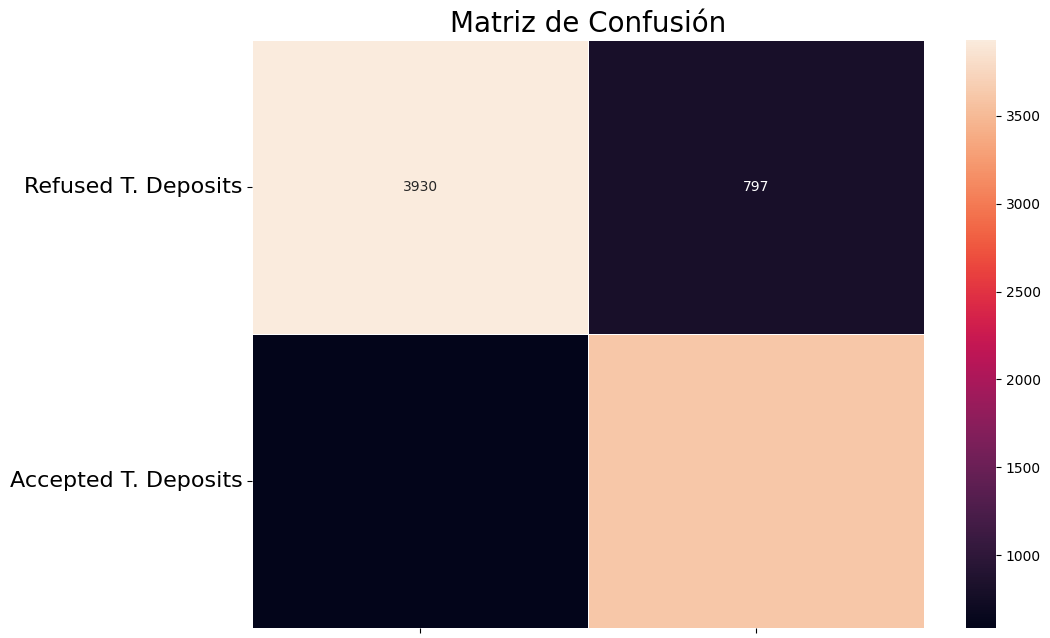

In [667]:
from sklearn.metrics import confusion_matrix
# 4697: no's, 4232: yes
conf_matrix = confusion_matrix(y_train, y_train_pred)
f, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d", linewidths=.5, ax=ax)
plt.subplots_adjust(left=0.15, right=0.99, bottom=0.15, top=0.99)
ax.set_yticks(np.arange(conf_matrix.shape[0]) + 0.5, minor=False)
ax.set_xticklabels("")
ax.set_yticklabels(['Refused T. Deposits', 'Accepted T. Deposits'], fontsize=16, rotation=360)
ax.set_title("Matriz de Confusión", fontsize = 20)
plt.show()

In [668]:
# Let's find the scores  for precision and recall.
from sklearn.metrics import precision_score, recall_score
# The model is 77% sure that the potential client will suscribe to a term deposit. 
# The model is only retaining 60% of clients that agree to suscribe a term deposit.
print('Precision Score: ', precision_score(y_train, y_train_pred))
# The classifier only detects 60% of potential clients that will suscribe to a term deposit.
print('Recall Score: ', recall_score(y_train, y_train_pred))
from sklearn.metrics import f1_score
f1 = f1_score(y_train, y_train_pred)
print(f'F1 Score = {f1}')

Precision Score:  0.8193563009972802
Recall Score:  0.8603046168491195
F1 Score = 0.8393313211051776


In [669]:
# hack to work around issue #9589 introduced in Scikit-Learn 0.19.0
if y_scores.ndim == 2:
    y_scores = y_scores[:, 1]

if neural_y_scores.ndim == 2:
    neural_y_scores = neural_y_scores[:, 1]
    
if naives_y_scores.ndim == 2:
    naives_y_scores = naives_y_scores[:, 1]

In [670]:
from sklearn.metrics import roc_curve
# Gradient Boosting Classifier
# Neural Classifier
# Naives Bayes Classifier
grd_fpr, grd_tpr, thresold = roc_curve(y_train, y_scores)
neu_fpr, neu_tpr, neu_threshold = roc_curve(y_train, neural_y_scores)
nav_fpr, nav_tpr, nav_threshold = roc_curve(y_train, naives_y_scores)

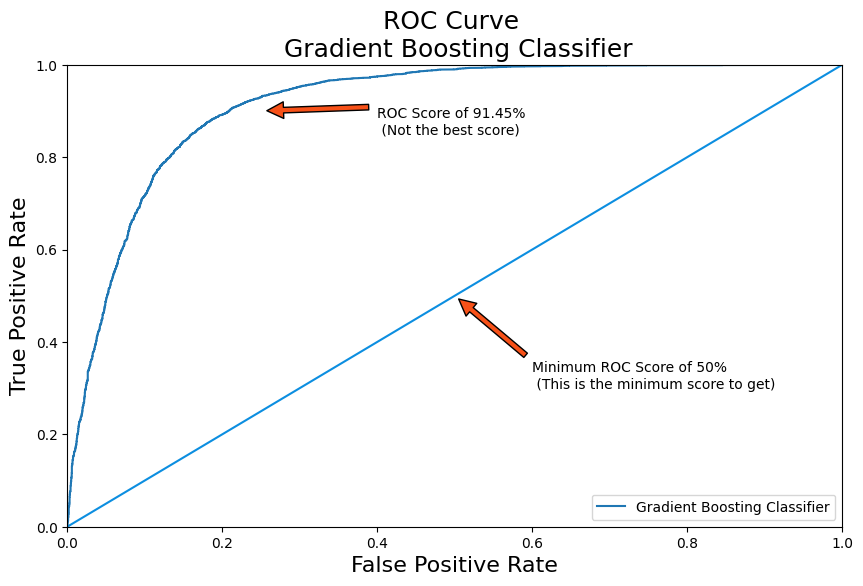

In [671]:
def graph_roc_curve(false_positive_rate, true_positive_rate, label=None):
    plt.figure(figsize=(10,6))
    
    # Create an axis object
    ax = plt.gca()
    
    ax.set_title('ROC Curve \n Gradient Boosting Classifier', fontsize=18)
    
    # Changed this line to use a string label instead of an array
    plt.plot(false_positive_rate, true_positive_rate, label="Gradient Boosting Classifier")
    
    plt.plot([0, 1], [0, 1], '#0C8EE0')
    plt.axis([0, 1, 0, 1])
    
    ax.set_xlabel('False Positive Rate', fontsize=16)
    ax.set_ylabel('True Positive Rate', fontsize=16)
    
    plt.annotate('ROC Score of 91.45% \n (Not the best score)', 
                xy=(0.25, 0.9), 
                xytext=(0.4, 0.85),
                arrowprops=dict(facecolor='#F75118', shrink=0.05))
    
    plt.annotate('Minimum ROC Score of 50% \n (This is the minimum score to get)', 
                xy=(0.5, 0.5), 
                xytext=(0.6, 0.3),
                arrowprops=dict(facecolor='#F75118', shrink=0.05))
    
    # Always show legend since we're using a string label now
    plt.legend()
    
# Changed this line to not pass threshold as a label
graph_roc_curve(grd_fpr, grd_tpr)
plt.show()

In [672]:
from sklearn.metrics import roc_auc_score

print('Gradient Boost Classifier Score: ', roc_auc_score(y_train, y_scores))
print('Neural Classifier Score: ', roc_auc_score(y_train, neural_y_scores))
print('Naives Bayes Classifier: ', roc_auc_score(y_train, naives_y_scores))

Gradient Boost Classifier Score:  0.9145508495405545
Neural Classifier Score:  0.8757701184331315
Naives Bayes Classifier:  0.7955675201559655


# RANKING IMPORTANCIA DE VARIABLES

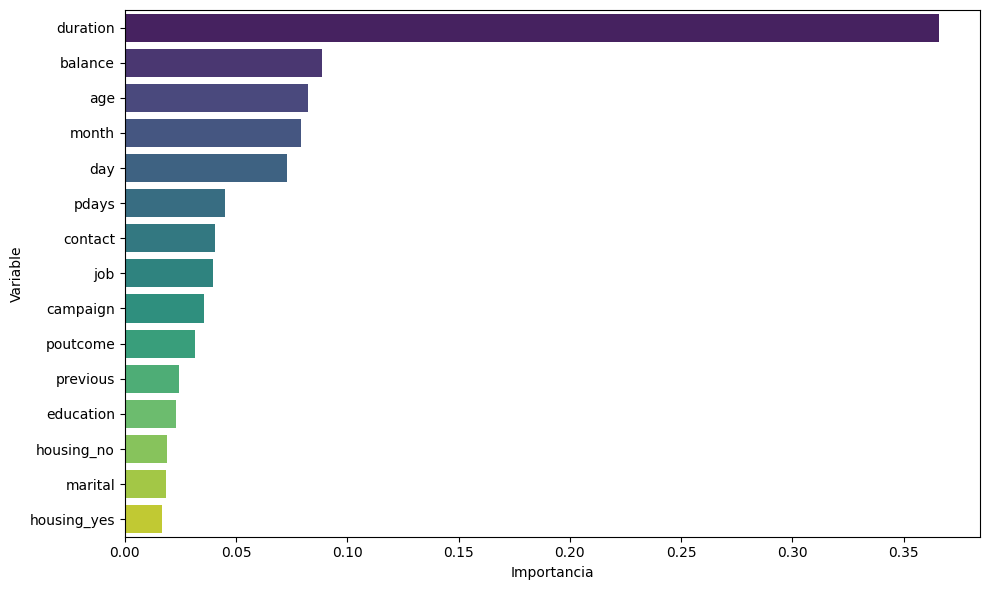

In [721]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Entrenar el modelo
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X, y)

# Obtener la importancia de las variables
importancias = modelo_rf.feature_importances_

# Crear DataFrame con las importancias
ranking_importancia = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# Mostrar las 15 más importantes
top_variables = ranking_importancia.head(15)

# 🎨 Gráfico
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=top_variables, palette='viridis')
ax.set_title('Top 15 Variables más Importantes - Random Forest')
ax.set_xlabel('Importancia')
ax.set_ylabel('Variable')
plt.tight_layout()
plt.show()
